In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv("../data/cleaned_data.csv")
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (50000, 27)


In [10]:
df['interview_score'] = (
    df['technical_score'] + 
    df['aptitude_score'] + 
    df['communication_score']
) / 3

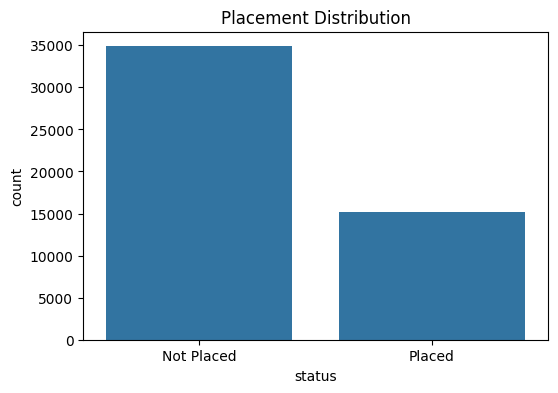

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x='status', data=df)
plt.title("Placement Distribution")
plt.show()

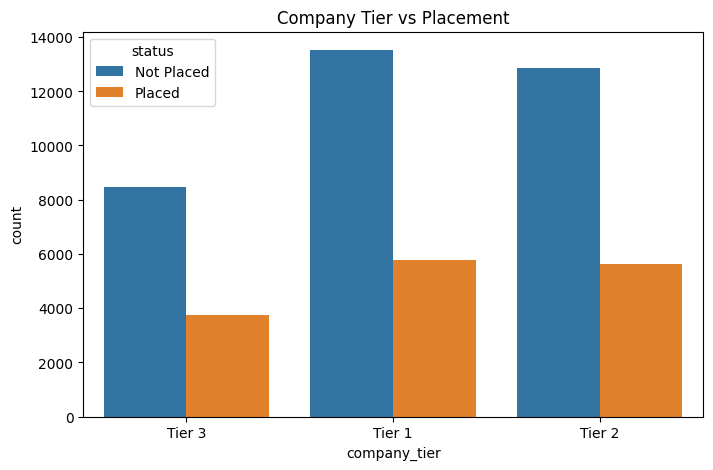

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(x='company_tier', hue='status', data=df)
plt.title("Company Tier vs Placement")
plt.show()


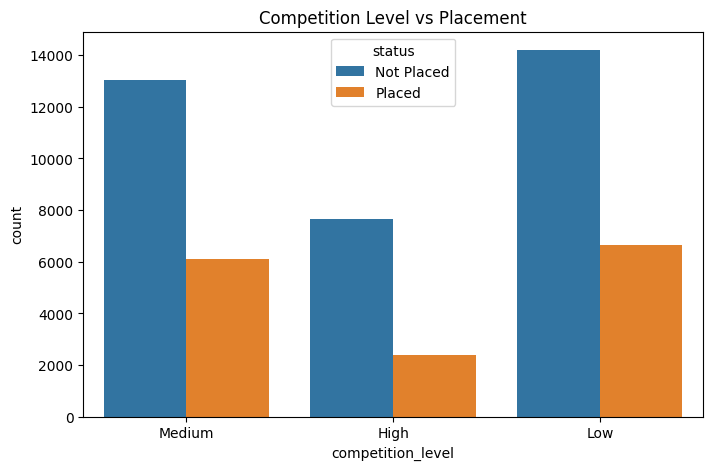

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x='competition_level', hue='status', data=df)
plt.title("Competition Level vs Placement")
plt.show()


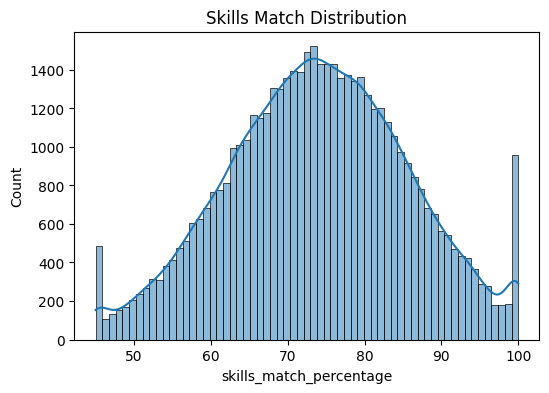

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['skills_match_percentage'], kde=True)
plt.title("Skills Match Distribution")
plt.show()


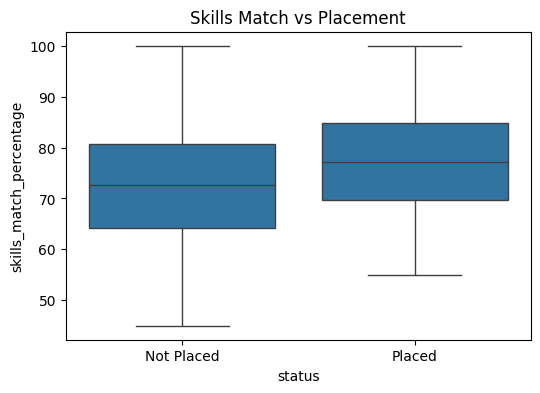

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x='status', y='skills_match_percentage', data=df)
plt.title("Skills Match vs Placement")
plt.show()

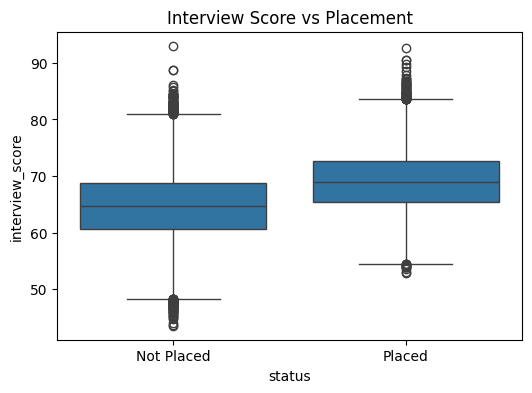

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='status', y='interview_score', data=df)
plt.title("Interview Score vs Placement")
plt.show()


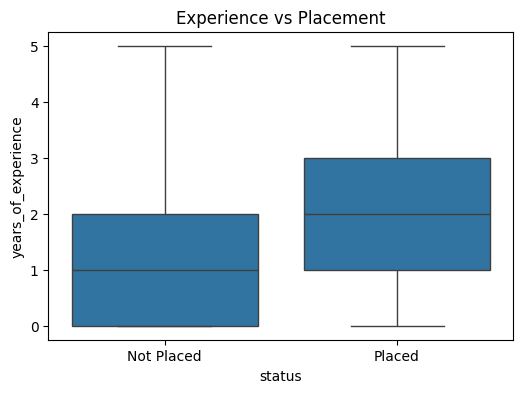

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='status', y='years_of_experience', data=df)
plt.title("Experience vs Placement")
plt.show()

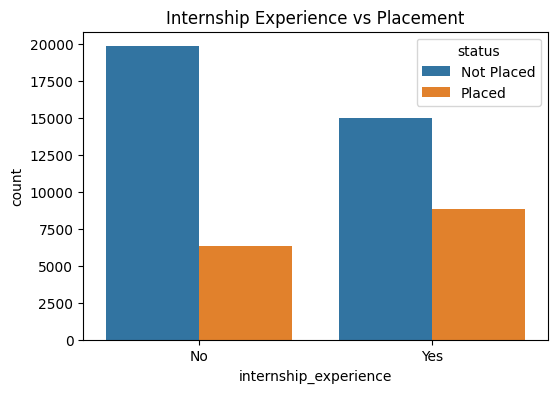

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='internship_experience', hue='status', data=df)
plt.title("Internship Experience vs Placement")
plt.show()

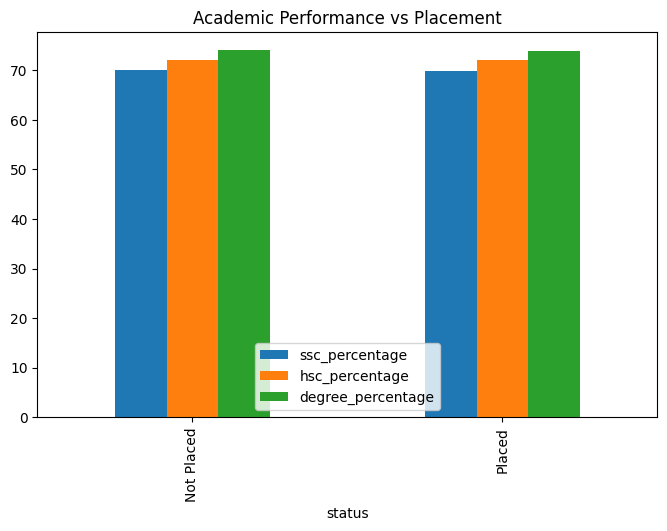

In [14]:
academic = df.groupby('status')[['ssc_percentage','hsc_percentage','degree_percentage']].mean()

academic.plot(kind='bar', figsize=(8,5))
plt.title("Academic Performance vs Placement")
plt.show()

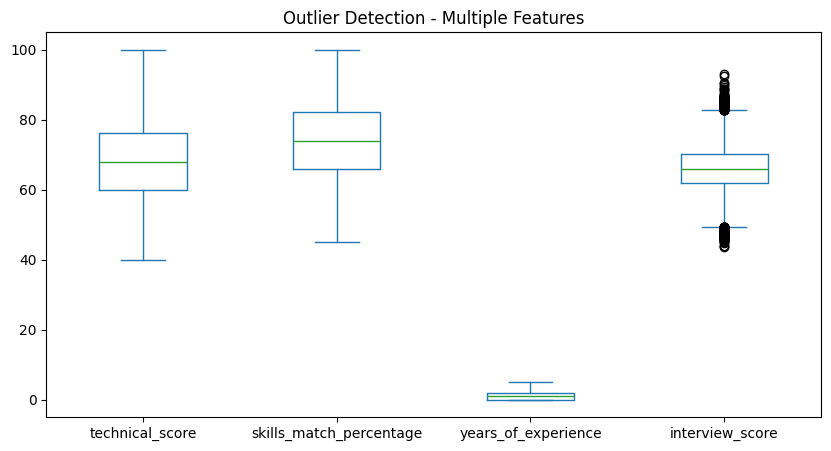

In [20]:
numeric_cols = [
    'technical_score',
    'skills_match_percentage',
    'years_of_experience',
    'interview_score'
]

df[numeric_cols].plot(kind='box', figsize=(10,5))
plt.title("Outlier Detection - Multiple Features")
plt.show()


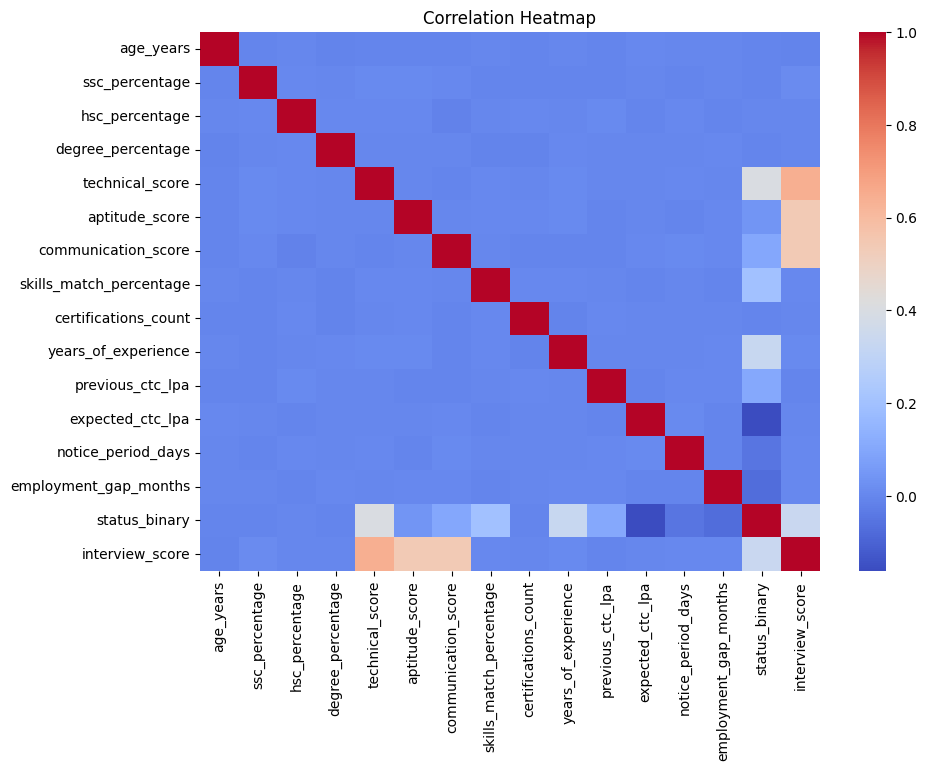

In [21]:
plt.figure(figsize=(10,7))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [22]:
status_binary = (df['status'] == 'Placed').astype(int)

corrs = df.select_dtypes(include=[np.number]).corrwith(status_binary).sort_values(ascending=False)

print("\nTop Factors Influencing Placement:")
print(corrs.head(10))


Top Factors Influencing Placement:
status_binary              1.000000
technical_score            0.403706
interview_score            0.335114
years_of_experience        0.331100
skills_match_percentage    0.198423
previous_ctc_lpa           0.101480
communication_score        0.097831
aptitude_score             0.039565
hsc_percentage            -0.002665
ssc_percentage            -0.003825
dtype: float64
